In [1]:
!pip install mlflow

In [51]:
import mlflow
import torch
import os
from torchvision import datasets,  models, transforms
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Subset, WeightedRandomSampler, DataLoader
import copy
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [3]:
torch.backends.cudnn.benchmark = True

In [4]:
#set global random seeds for Python, numpy, pytorch, and CUDA to ensure 100% reproducibility of model weights and data shuffling
def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [5]:
set_seed(42)

# Plant Disease Classification using EfficientNet-B0 Transfer learning and explainable AI with Grad-CAM

## Introduction

The primary objective of this project is automated Plant Disease Classification utilizing deep convolutional neural networks (CNNs). The dataset used is Plant Diseases dataset sourced from Kaggle/https://www.kaggle.com/datasets/saroz014/plant-diseases. It contains images of crop leaves categorized into 38 distinct classes: 23 classes representing various plant phytopathologies and 15 classes with healthy plant leaves. The dataset is structured into two main parts: Train folder containing approx. 173,000 images and a test folder containing approx. 43,000 images.
#Methodology Framework:

## 1. MLflow Integration
MLOps framework - MLflow is integrated into the experimental setup. MLflow tracking server monitors training metrics in real time. This architecture allows for systematic logging of the loss and accuracy per epoch.

## 2. Data preprocessing and Augmentation
Input image transformations were applied to standardize the data and artificially expand the dataset variety. This included resizing to 224 × 224 pixels, random horizontal/vertical flips, and tensor normalization based on ImageNet channel statistics.

## 3. Exploratory data analysis (EDA)
This step includes generating a class distribution analysis and visual inspection grids to evaluate data quality, verify image characteristics, and map the exact sample distribution across all 38 categories.

## 4. Dataset stratification
I split the training folder into two parts using a 90/10 ratio. I get train_data (90% for training) and val_data (10% for validation). I use stratified splitting, which means both parts keep the exact same percentages for all 38 diseases.


## 5. Class imbalance assessment and sampling strategy
Based on the outcomes of the EDA phase, the workflow integrates a conditional balancing strategy. If a significant class imbalance is detected, a **WeightedRandomSampler** will be configured. This sampler calculates a specific weight for each category based strictly on the 90% remaining training set so that rare classes receive a higher probability of being selected, while very common classes receive lower weights using the formula:

$$P_i = \frac{1}{\text{count}(\text{class}_i)}$$

This approach is planned to ensure that the model encounters an evenly distributed mix of plant pathologies during training, preventing the network from developing a bias toward majority classes.


## 6. Transfer Learning and classifier design

For transfer learning I utilized EfficientNet-B0, a convolutional neural network pre-trained on more than one million images from the ImageNet database. Capable of classifying images into 1000 object categories the network learned rich feature representations across a wide range of images. EfficientNet-B0 requires an image input size of 224x224 pixels and the dataset was resized to these dimensions. EfficientNet has scaling method, which uniformly scales all dimensions of depth, width, and resolution, enable the model to achieve maximum accuracy gains efficiently.
All deep convolutional layers responsible for feature extraction were frozen. The default classifier head was replaced with a custom sequential architecture containing a **Dropout layer (p = 0.2) for regularization** and a **Linear layer** mapping the 1,280 extracted features to the 38 output classes.

## 7. Model training and optimization

The model was optimized using the **Adam optimizer** with a **learning rate (lr = 0.0001)**. The optimization criterion is the **Cross-Entropy Loss**, which evaluates the model's performance by measuring the difference between the predicted probability distributions and the true labels:

$$ \text{Loss} = -\sum_{c=1}^{M} y_c \log(p_c) $$

Where $M = 38$ is the total number of plant disease classes. The variable $y_c$ acts as a binary indicator (it equals for the correct disease class, and 0 for all other 37 incorrect classes). The predicted probability $p_c$ for each class is calculated by applying the Softmax function to the model's raw outputs ($z_c$):

$$ p_c = \frac{e^{z_c}}{\sum_{j=1}^{M} e^{z_j}} $$


## 8. Evaluation and visualization
* Learning curves (training and validation curves):
Generated dynamically using the **MLflowClient API** to plot Loss vs. Epochs and Accuracy vs. Epochs. These curves demonstrate model convergence and verify the absence of overfitting.
* Normalized confusion matrix: A 38 × 38 heatmap displaying accuracy percentages for each class.

## 9. Failure modes analysis
Analysis of the images where the model made wrong predictions. I will plot a gallery of the top mistakes to see exactly why the model got confused.

## 10. Explainable AI (XAI) with Grad-CAM
Apply Gradient-weighted Class Activation Mapping (Grad-CAM) to validate the visual reliability of the network. This technique generates colorful heatmaps over the leaves to show exactly which pixel areas and lesions the model focuses on to make its final decision.

## 11. Final Model test
Evaluate the finalized weights of the trained model against the independent test dataset to obtain the definitive baseline accuracy of the computer vision workflow.

## Conclusion



## 1. MLflow Integration

In [6]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

In [7]:
mlflow.set_tracking_uri("file:./mlruns")

In [8]:
mlflow.set_experiment("Plant_Disease_Classification_Final_Run1")

<Experiment: artifact_location='file:C:/Users/Petar/Desktop/New folder/Project/mlruns/962836697642417283', creation_time=1783333695092, effective_trace_archival_retention=None, experiment_id='962836697642417283', last_update_time=1783333695092, lifecycle_stage='active', name='Plant_Disease_Classification_Final_Run1', tags={}, trace_location=None, workspace='default'>

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
device

device(type='cuda')

In [11]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 5070 Ti


## 2. Data preprocessing and Augmentation

### Dataset loading

In [12]:
train_dir = r'C:\Users\Petar\Desktop\New folder\air\plant dataset\dataset_itr2\train'
test_dir = r'C:\Users\Petar\Desktop\New folder\air\plant dataset\dataset_itr2\test'

I applied several input image transformations to the training data in order to artificially expand the dataset variety and to prevent overfitting. This includes random cropping and resizing, and random horizontal flips.
The **ToTensor()** function is utilized to convert the raw images into PyTorch tensors. Additionally, for data standardization, I configured the normalization layer using the standard ImageNet channel statistics. The images were normalized with a specific mean of [0.485, 0.456, 0.406] and a standard deviation of [0.229, 0.224, 0.225]. The mathematical formula is:
$$\text{image}=\frac{\text{image}-\text{mean}}{\text{std}}$$
This scaling improves and speeds up neural network training because the input data is centered around a zero value and shares the similar distribution. Also, this scaling matches the exact pixel domain that the pre-trained EfficientNet backbone expects, accelerating model training and convergence.

In [13]:
#data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [14]:
#loading datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform = data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform = data_transforms['test'])

## 3. Exploratory data analysis

In [15]:
class_names = full_train_dataset.classes

In [16]:
class_counts = np.bincount(full_train_dataset.targets)

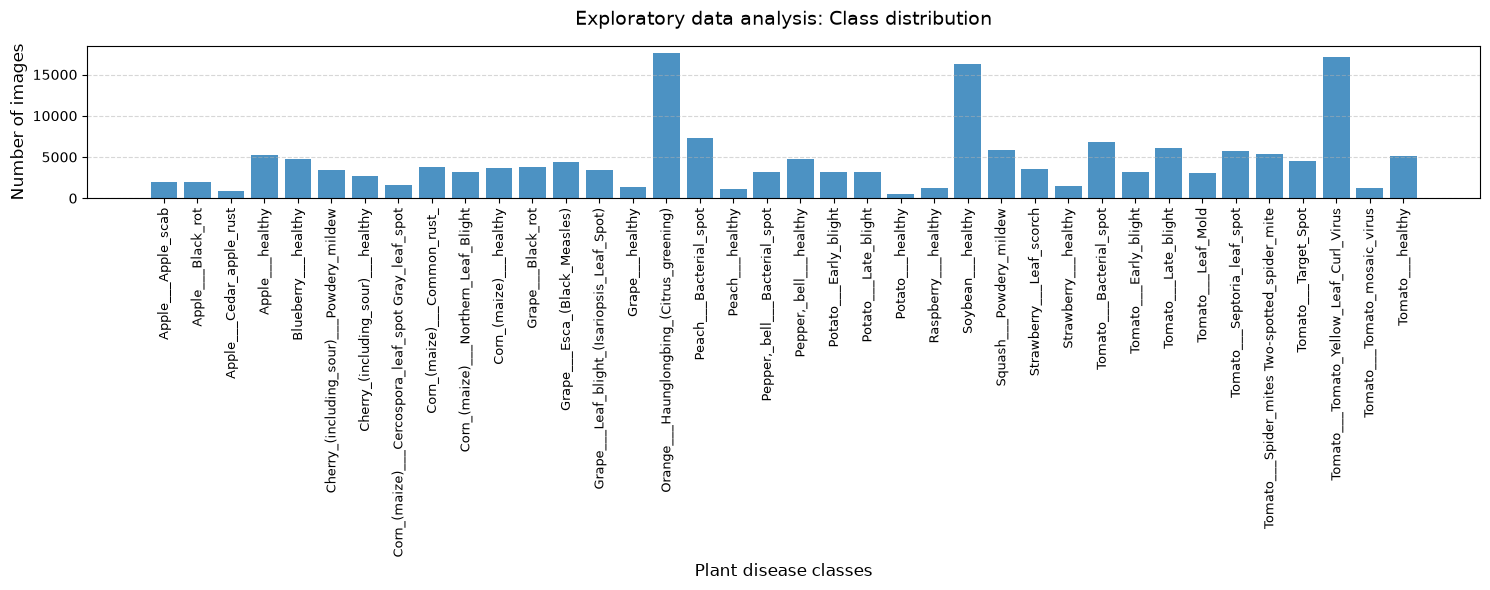

In [17]:
plt.figure(figsize = (15, 6))
plt.bar(class_names, class_counts, alpha = 0.8)
plt.title('Exploratory data analysis: Class distribution', fontsize = 14, pad = 15)
plt.xlabel('Plant disease classes', fontsize = 12)
plt.ylabel('Number of images', fontsize = 12)
plt.xticks(rotation = 90, fontsize = 9)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

The analysis chart reveals a significant class imbalance across the 38 plant categories. The image distribution is highly unbalanced, with some rare diseases containing only 400-500 samples, while dominant categories exceed 17,000 images. Model trainig on such skewed data would cause a severe bias toward the majority classes, leading to low accuracy on rare diseases. To mitigate this issue, I will implement **WeightedRandomSampler** in the training phase. This sampler calculates a specific weight for each category so that rare classes receive a higher probability of being selected, while very common classes receive lower weights, forcing the model to learn from all plant diseases equally.

In [18]:
#Dataset analysis: class distribution
class_counts = {folder: len(os.listdir(os.path.join(train_dir, folder))) for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))}

In [19]:
for class_name, count in sorted(class_counts.items(), key = lambda x: x[1], reverse = True):
    print(f"Class: {class_name:<30} | Count images: {count}")

Class: Orange___Haunglongbing_(Citrus_greening) | Count images: 17624
Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus | Count images: 17144
Class: Soybean___healthy              | Count images: 16288
Class: Peach___Bacterial_spot         | Count images: 7352
Class: Tomato___Bacterial_spot        | Count images: 6808
Class: Tomato___Late_blight           | Count images: 6109
Class: Squash___Powdery_mildew        | Count images: 5872
Class: Tomato___Septoria_leaf_spot    | Count images: 5668
Class: Tomato___Spider_mites Two-spotted_spider_mite | Count images: 5364
Class: Apple___healthy                | Count images: 5264
Class: Tomato___healthy               | Count images: 5089
Class: Blueberry___healthy            | Count images: 4808
Class: Pepper,_bell___healthy         | Count images: 4725
Class: Tomato___Target_Spot           | Count images: 4496
Class: Grape___Esca_(Black_Measles)   | Count images: 4428
Class: Corn_(maize)___Common_rust_    | Count images: 3816
Class: Grape___Black

### Random images

In [20]:
random_indices = random.sample(range(len(full_train_dataset)), 8)

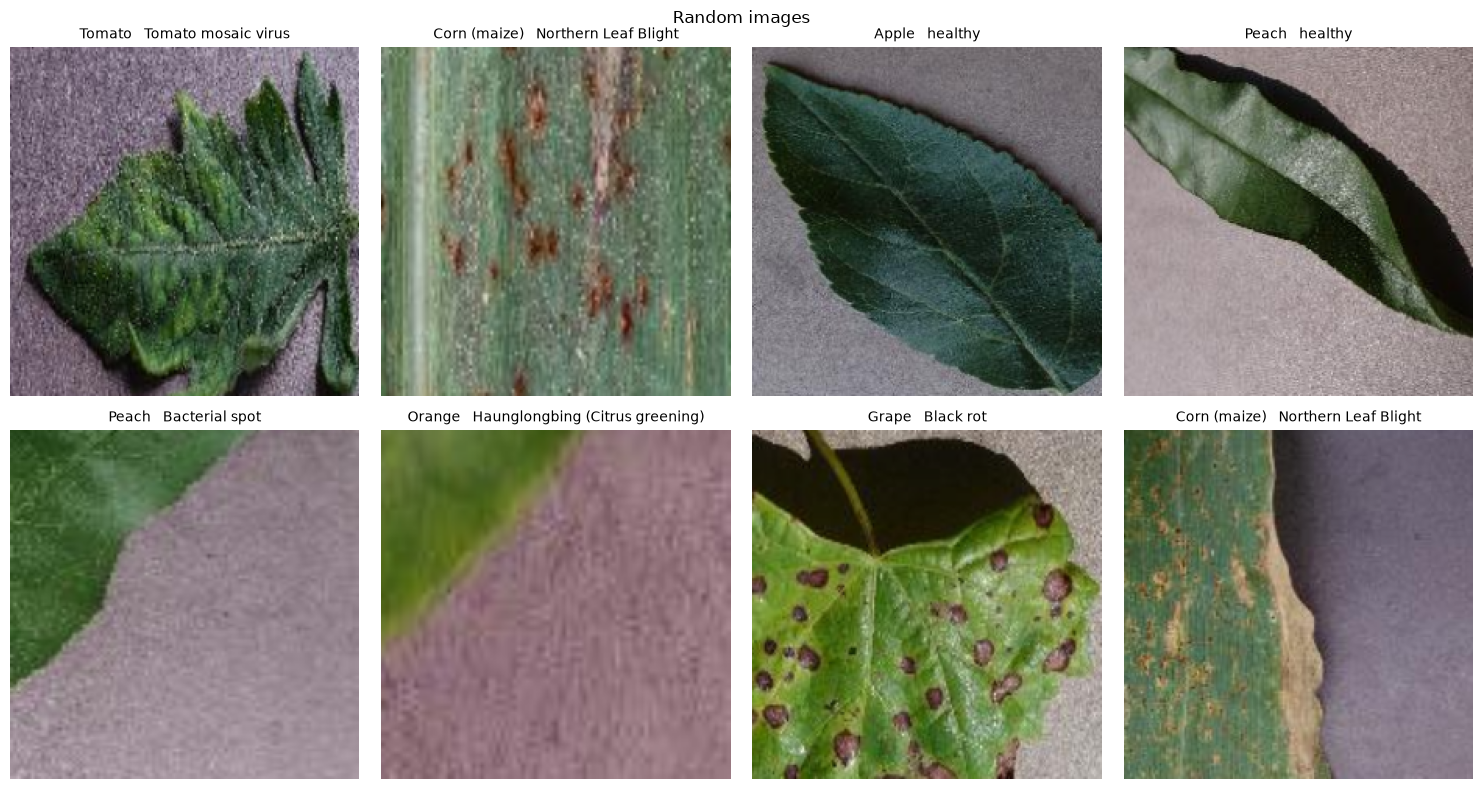

In [21]:
plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
  image, label = full_train_dataset[idx]
  class_name = full_train_dataset.classes[label]

  #invert ImageNet normalization to restore original pixel range
  img = image.permute(1, 2, 0).numpy()
  img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

  plt.subplot(2, 4, i + 1)
  plt.imshow(img)

  if '___' in class_names:
    parts = class_name.split('___')
    plant = parts[0].replace('_', ' ')
    condition = parts[1].replace('_', ' ')
    display_title = f"{plant}\n({condition})"
  else:
        display_title = class_name.replace('_', ' ')
  plt.title(display_title, fontsize = 10)
  plt.axis('off')

plt.suptitle("Random images")
plt.tight_layout(h_pad=3.0)
plt.show()

## 4. Data stratification

In [22]:
all_train_indices = list(range(len(full_train_dataset)))
all_train_labels = torch.tensor(full_train_dataset.targets)

**all_train_indices** creates a simple list of numbers from 0 to 217,000. Each photo gets its own number. This saves computer memory (RAM).\
**all_train_labels** convert the list of folder/class indices into a PyTorch tensor for stratification math

In [23]:
#stratification - 0.9 for train_indices and 0.1 for val_indices
train_indices = []
val_indices = []

#stratification
for class_idx in torch.unique(all_train_labels):
  class_indices = (all_train_labels == class_idx).nonzero(as_tuple = True)[0] #get the images with True

  #random shuffling
  perm = torch.randperm(len(class_indices), generator = torch.Generator().manual_seed(42))
  class_indices = class_indices[perm]

  #get 10% for val set
  val_size = int(len(class_indices) * 0.1)
  val_indices.extend(class_indices[:val_size].tolist())
  train_indices.extend(class_indices[val_size:].tolist())


First I create two empty lists, train_indices and val_indices, to act as containers for storing the final image numbers. I use a for loop to enter each of the 38 categories one by one. This step guarantees the stratification process. Inside the loop, I find the exact location of all images belonging to the current category. Then, I shuffle these data randomly using torch.randperm. I also use a fix manual_seed to lock the randomness so the results are always reproducible. Finally, I extract 10% of the shuffled data per category and moved them to val_indices. The remaining 90% went to train_indices.

In [24]:
#create virtual subsets based on stratified indices to split data without duplicating images in RAM
train_data = Subset(full_train_dataset, train_indices)
val_data = Subset(full_train_dataset, val_indices)

This approach creates virtual datasets that simply wrap around the original data using the calculated stratified indices. Images are only read from the disk when the model requests them during training or validation, which makes this process memory-efficient.

In [25]:
val_data.dataset = copy.deepcopy(full_train_dataset)

In [26]:
val_data.dataset.transform = data_transforms['test']

Validation data needs raw, not augmented data. Therefore I create a deep copy of the original dataset structure for val_data and apply the same clean transformations as the test set, only resizing and cropping, without any random flips.

In [27]:
len(train_data), len(val_data)

(156445, 17363)

In [28]:
image, label = train_data[50]

In [29]:
image.shape, label

(torch.Size([3, 224, 224]), 0)

In [30]:
train_data.indices[:10]

[1910, 1500, 699, 483, 673, 1181, 1045, 1917, 1862, 636]

In [31]:
val_data.indices[:10]

[582, 633, 564, 490, 1202, 1986, 496, 75, 1262, 569]

## 5. Class imbalance assessment and sampling strategy

Here I apply WeightedRandomSampler to fix the problem with unbalanced data. First, I extract the labels for the training subset to compute the exact class frequencies.

In [32]:
train_targets = [all_train_labels[i].item() for i in train_indices]

 Then I calculate the class weights using the inverse class frequency method. This creates a specific weight for every individual sample, ensuring that rare categories have a higher probability of being selected during training, while common categories are heavily down-weighted.

In [33]:
counts_array = np.bincount(train_targets)

In [34]:
class_weights = 1 / counts_array

In [35]:
sample_weights = [class_weights[t] for t in train_targets]

In [36]:
sampler = WeightedRandomSampler(weights = sample_weights, num_samples = len(sample_weights), replacement=True)

WeightedRandomSampler with replacement = True use the calculated weights to change the selection probability for each image. This allows PyTorch to select rare images multiple times and common images less often, creating a balanced stream of data for the model while keeping the total training size the same.

In [37]:
batch_size = 32

In [38]:
train_loader = DataLoader(train_data, batch_size = batch_size, sampler = sampler, num_workers = 4, pin_memory = True)
val_loader = DataLoader(val_data, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory = True)

The DataLoader loads the image pixels and labels in small batches of 32.  This process saves RAM memory because the computer reads only 32 images at a time. The train_loader uses sampler to ensure every batch is balanced, while val_loader and test_loader keep shuffle = False to evaluate the model on the clean, sequential data.

## 6. Transfer Learning and classifier design

I load the EfficientNet-B0 model with its default pre-trained weights (EfficientNet_B0_Weights.DEFAULT). To use the features that the network already knows and stop them from changing, I froze all the base weights by setting requires_grad = False. Then I adopt the original classifier for my dataset. I take the number of input features from the last layer and replace the default classifier with a custom nn.Sequential block. Inside I put a Dropout layer with a 0.2 probability to prevent overfitting, followed by a Linear layer to map the features to my specific number of classes. Then I move the model to the computing device.

In [39]:
#load efficientnetB0
model = efficientnet_b0(weights = EfficientNet_B0_Weights.DEFAULT)

In [40]:
#freeze the base weights
for param in model.parameters():
    param.requires_grad = False

In [41]:
#get the number of input features 1280 from the original model EfficientNet-B0
in_features = model.classifier[1].in_features

In [42]:
num_classes = len(counts_array)

In [43]:
#replace the original classifier with a custom head for out specific dataset
model.classifier = nn.Sequential(
    nn.Dropout(p = 0.2),
    nn.Linear(in_features, num_classes)
)

In [44]:
model = model.to(device)

## 7. Model training and optimization

I freeze all base convolutional layers. This preserves the visual features learned from ImageNet. Training is limited only to the new classification layer. This custom layer is designed specifically for our dataset. This approach sets a baseline performance for plant disease classification.

In [45]:
def train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs, run_name):
    criterion = nn.CrossEntropyLoss()
    best_accuracy = 0.0

    with mlflow.start_run(run_name=run_name):
        #log the static hyperparameters to MLflow dashboard
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", train_loader.batch_size)
        mlflow.log_param("model_architecture", "EfficientNet-B0")
        mlflow.log_param("optimizer", type(optimizer).__name__)
        mlflow.log_param("loss_function", "CrossEntropyLoss")
        mlflow.log_param("image_size", "224x224")
        mlflow.log_param("num_classes", model.classifier[1].out_features)

        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")

            #training mode
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            pbar = tqdm(train_loader, desc = f"Epoch {epoch + 1} - Training")
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                _, preds = torch.max(outputs, 1)
                train_correct += (preds == labels).sum().item()
                train_total += labels.size(0)
                train_loss += loss.item() * inputs.size(0)

            epoch_train_loss = train_loss / train_total
            epoch_train_acc = train_correct / train_total

            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)

                    _, preds = torch.max(outputs, 1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            epoch_val_loss = val_loss / val_total
            epoch_val_acc = val_correct / val_total

            
            print(
                f"Train loss: {epoch_train_loss:.4f} | Train accuracy: {epoch_train_acc:.4f} | "
                f"Val loss: {epoch_val_loss:.4f} | Val accuracy: {epoch_val_acc:.4f}"
            )

            if lr_scheduler is not None:
                lr_scheduler.step()

            
            mlflow.log_metric("train_loss", epoch_train_loss, step=epoch)
            mlflow.log_metric("train_accuracy", epoch_train_acc, step=epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step=epoch)
            mlflow.log_metric("val_accuracy", epoch_val_acc, step=epoch)
            

            
            path = "./plant_classification_checkpoints_final_project"
            os.makedirs(path, exist_ok=True)

            is_best = epoch_val_acc > best_accuracy
            if is_best:
                best_accuracy = epoch_val_acc

            checkpoint = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_accuracy": best_accuracy,
            }

            
            current_checkpoint_path = os.path.join(path, "last_checkpoint_final_project.pth")
            torch.save(checkpoint, current_checkpoint_path)
            print(f"Check point for epoch {epoch + 1} is saved locally.")

            
            if is_best:
                best_model_path = os.path.join(path, "best_model_final_project.pth")
                torch.save(checkpoint, best_model_path)
                print(f"The best model with validation accuracy: {best_accuracy:.2f}")

                mlflow.pytorch.log_model(model, artifact_path = "best_model_mlflow", serialization_format="pickle")


In [47]:
#mlflow.end_run()

In [48]:
optimizer = optim.Adam(model.classifier.parameters(), lr = 0.0001)

In [50]:
train_model(model, train_loader, val_loader, optimizer = optimizer, lr_scheduler = None, epochs = 10, run_name = "Plant_Class_Final_Project1")


Epoch 1/10


Epoch 1 - Training: 100%|██████████| 4889/4889 [01:24<00:00, 57.65it/s]
2026/07/06 17:18:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 17:18:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Train loss: 1.4714 | Train accuracy: 0.7121 | Val loss: 0.9896 | Val accuracy: 0.7343
Check point for epoch 1 is saved locally.
The best model with validation accuracy: 0.73


2026/07/06 17:18:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/06 17:18:36 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 2/10


...

Epoch 9 - Training: 100%|██████████| 4889/4889 [01:01<00:00, 79.54it/s]


Train loss: 0.4780 | Train accuracy: 0.8575 | Val loss: 0.5584 | Val accuracy: 0.8299
Check point for epoch 9 is saved locally.

Epoch 10/10


Epoch 10 - Training: 100%|██████████| 4889/4889 [01:02<00:00, 78.39it/s]
2026/07/06 17:29:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 17:29:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Train loss: 0.4717 | Train accuracy: 0.8593 | Val loss: 0.5143 | Val accuracy: 0.8437
Check point for epoch 10 is saved locally.
The best model with validation accuracy: 0.84


2026/07/06 17:29:58 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/06 17:30:01 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [51]:
mlflow.end_run()

In [52]:
checkpoint = torch.load("./plant_classification_checkpoints_final_project/best_model_final_project.pth")
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

The model reached a validation accuracy of 84,37% (and training accuracy 85,93%), and it become evident that training only the classifier was no longer enough for further improvement. The model quickly learned the general features from the base layers, but reached its performance limit. To break past this limit, in the next step I will implement a **fine-tuning strategy** by unfreezing the final convolutional block (Block 8). The early layers focus on basic shapes and colors, but this final block is responsible for detecting complex, specific patterns. Unfreezing it allows the network to adapt its filters directly to the specific visual details of plant diseases, helping the model make much more accurate predictions.

## 7.2 Fine-tuning

Adam is an adaptive optimizer, it looks at how each specific weight moved during past batches and automatically adjusts its speed. If a parameter shows large and consistent gradients, Adam maintains a higher effective learning rate to accelerate its training. This adaptive behavior allowed the model to learn very fast in the beginning, pulling the untrained classifier up to 84% accuracy baseline. After reaching this point, Adam hit a plateau and stalled.[2] \
Standard Adam can become overly aggressive during fine-tuning because it couples weight decay with adaptive gradient updates. This can cause erratic updates in unfrozen layers, leading to overfitting on background noise rather than focusing on leaf pathologies. Using AdamW avoids this problem and ensures the pre-trained layers learn smoothly
I chose AdamW for the fine-tune strategy . AdamW decouples weight decay (weight_decay = 0.01) from gradient updates, which prevents overfitting and keeps the pre-trained ImageNet features stable during training.
Different parts of the network have different needs, I split the parameters into two groups with discriminative learning rates:
* Block 8 (lr = 0.00001): A very small step size ensures that we gently fine-tune the existing deep visual filters without destroying what the model learned from ImageNet and prevent from catastrophic forgetting.
* Classifier head (lr = 0.0001): A Larger step size allows the output layer to adapt quickly to the new refined features coming from Block 8.
Keeping the early layers frozen preserves universal visual features and prevents the model from overfitting. This strategy protects the pre-trained ImageNet weights in the earlier layers from being overwritten, preserving their general visual features.

In [53]:
for param in model.features[8].parameters():
    param.requires_grad = True

In [54]:
optimizer = optim.AdamW([
    {'params': model.features[8].parameters(), 'lr': 0.00001},
    {'params': model.classifier.parameters(),  'lr': 0.0001}], weight_decay = 0.01)

In [58]:
train_model(model, train_loader, val_loader, optimizer = optimizer, lr_scheduler = None, epochs = 5, run_name = "Plant_Class_Final_Project1_Fine_Tuning"
)


Epoch 1/5


Epoch 1 - Training: 100%|██████████| 4889/4889 [01:05<00:00, 74.89it/s]
2026/07/06 18:06:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 18:06:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/06 18:06:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Train loss: 0.4248 | Train accuracy: 0.8708 | Val loss: 0.5071 | Val accuracy: 0.8433
Check point for epoch 1 is saved locally.
The best model with validation accuracy: 0.84


2026/07/06 18:06:07 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 2/5


...

Train loss: 0.3697 | Train accuracy: 0.8856 | Val loss: 0.3463 | Val accuracy: 0.8910
Check point for epoch 4 is saved locally.
The best model with validation accuracy: 0.89


2026/07/06 18:10:04 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 5/5


Epoch 5 - Training: 100%|██████████| 4889/4889 [01:02<00:00, 78.15it/s]


Train loss: 0.3509 | Train accuracy: 0.8916 | Val loss: 0.4141 | Val accuracy: 0.8717
Check point for epoch 5 is saved locally.


In [59]:
mlflow.end_run()

Applying fine-tuning by unfreezing Block 8 with AdamW unlocked further learning, with the validation loss dropping to 0.3463 and validation accuracy improving from 84.33% to 89.10% (on Epoch 4). However the overall improvement remains relatively modest. While the training process stabilized, the model showing signs of overfitting by Epoch 5, where the validation loss increase to 0.4141.This indicates that while selective unfreezing helps the network adapt to disease patterns, the model's overall capacity is still constrained.To find why the model makes mistakes and cant surpass this threshold, a detailed error analysis is required in the next steps.

## 8. Evaluation and visualization

### 8.1 Learning curves

In [82]:
client = mlflow.tracking.MlflowClient()
run_id = (mlflow.last_active_run() or client.search_runs(order_by=["attribute.start_time DESC"])).info.run_id

In [86]:
def get_exact_epoch_metrics(metric_name):
    history = client.get_metric_history(run_id, metric_name)
    #get last run
    step_dict = {p.step: p.value for p in history}
    sorted_steps = sorted(step_dict.keys())[-5:]
    return [step_dict[s] for s in sorted_steps]

In [84]:
train_loss = get_exact_epoch_metrics("train_loss")
val_loss   = get_exact_epoch_metrics("val_loss")
train_acc  = get_exact_epoch_metrics("train_accuracy")
val_acc    = get_exact_epoch_metrics("val_accuracy")

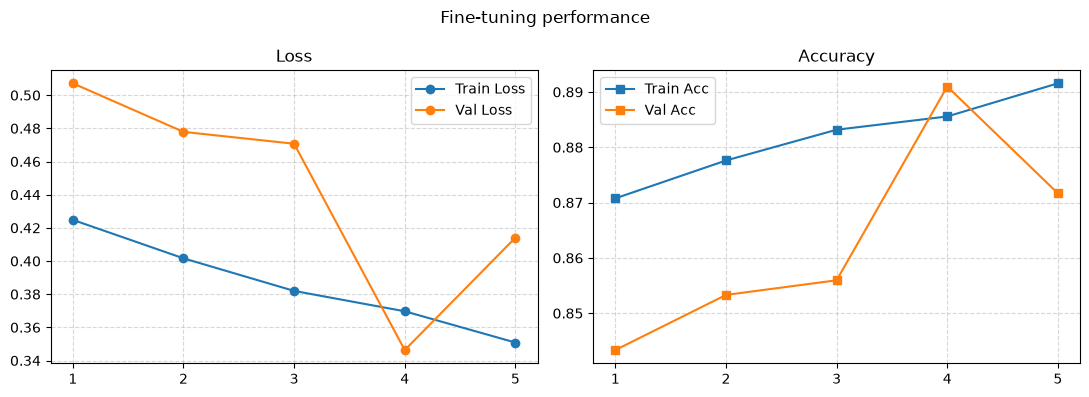

In [87]:
epochs = list(range(1, len(train_loss) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (11, 4))
fig.suptitle('Fine-tuning performance')

ax1.plot(epochs, train_loss, 'o-', label = 'Train Loss')
ax1.plot(epochs, val_loss, 'o-', label = 'Val Loss')
ax1.set_title('Loss'); ax1.set_xticks(epochs)
ax1.grid(True, ls = '--', alpha = 0.5)
ax1.legend()

ax2.plot(epochs, train_acc, 's-', label = 'Train Acc')
ax2.plot(epochs, val_acc, 's-', label = 'Val Acc')
ax2.set_title('Accuracy')
ax2.set_xticks(epochs)
ax2.grid(True, ls = '--', alpha = 0.5)
ax2.legend()

plt.tight_layout()
plt.show()

Training loss decreased steadily from 0.4248 down to 0.3509, while training accuracy improved from 87.08% to 89.16%, showing consistent learning. The optimal performance was achieved at Epoch 4, where validation loss reached its lowest point of 0.3463. Simultaneously validation accuracy achieved its peak at 89.10%. These metrics indicate that unfreezing Block 8 helped the network better capture specific visual patterns.

In [46]:
checkpoint = torch.load("./plant_classification_checkpoints_final_project/best_model_final_project.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [47]:
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [48]:
all_true = []
all_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

In [49]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)
class_names = full_train_dataset.classes

### 8.2. Confusion matrix

In [52]:
cm = confusion_matrix(all_true, all_pred, normalize = "true")

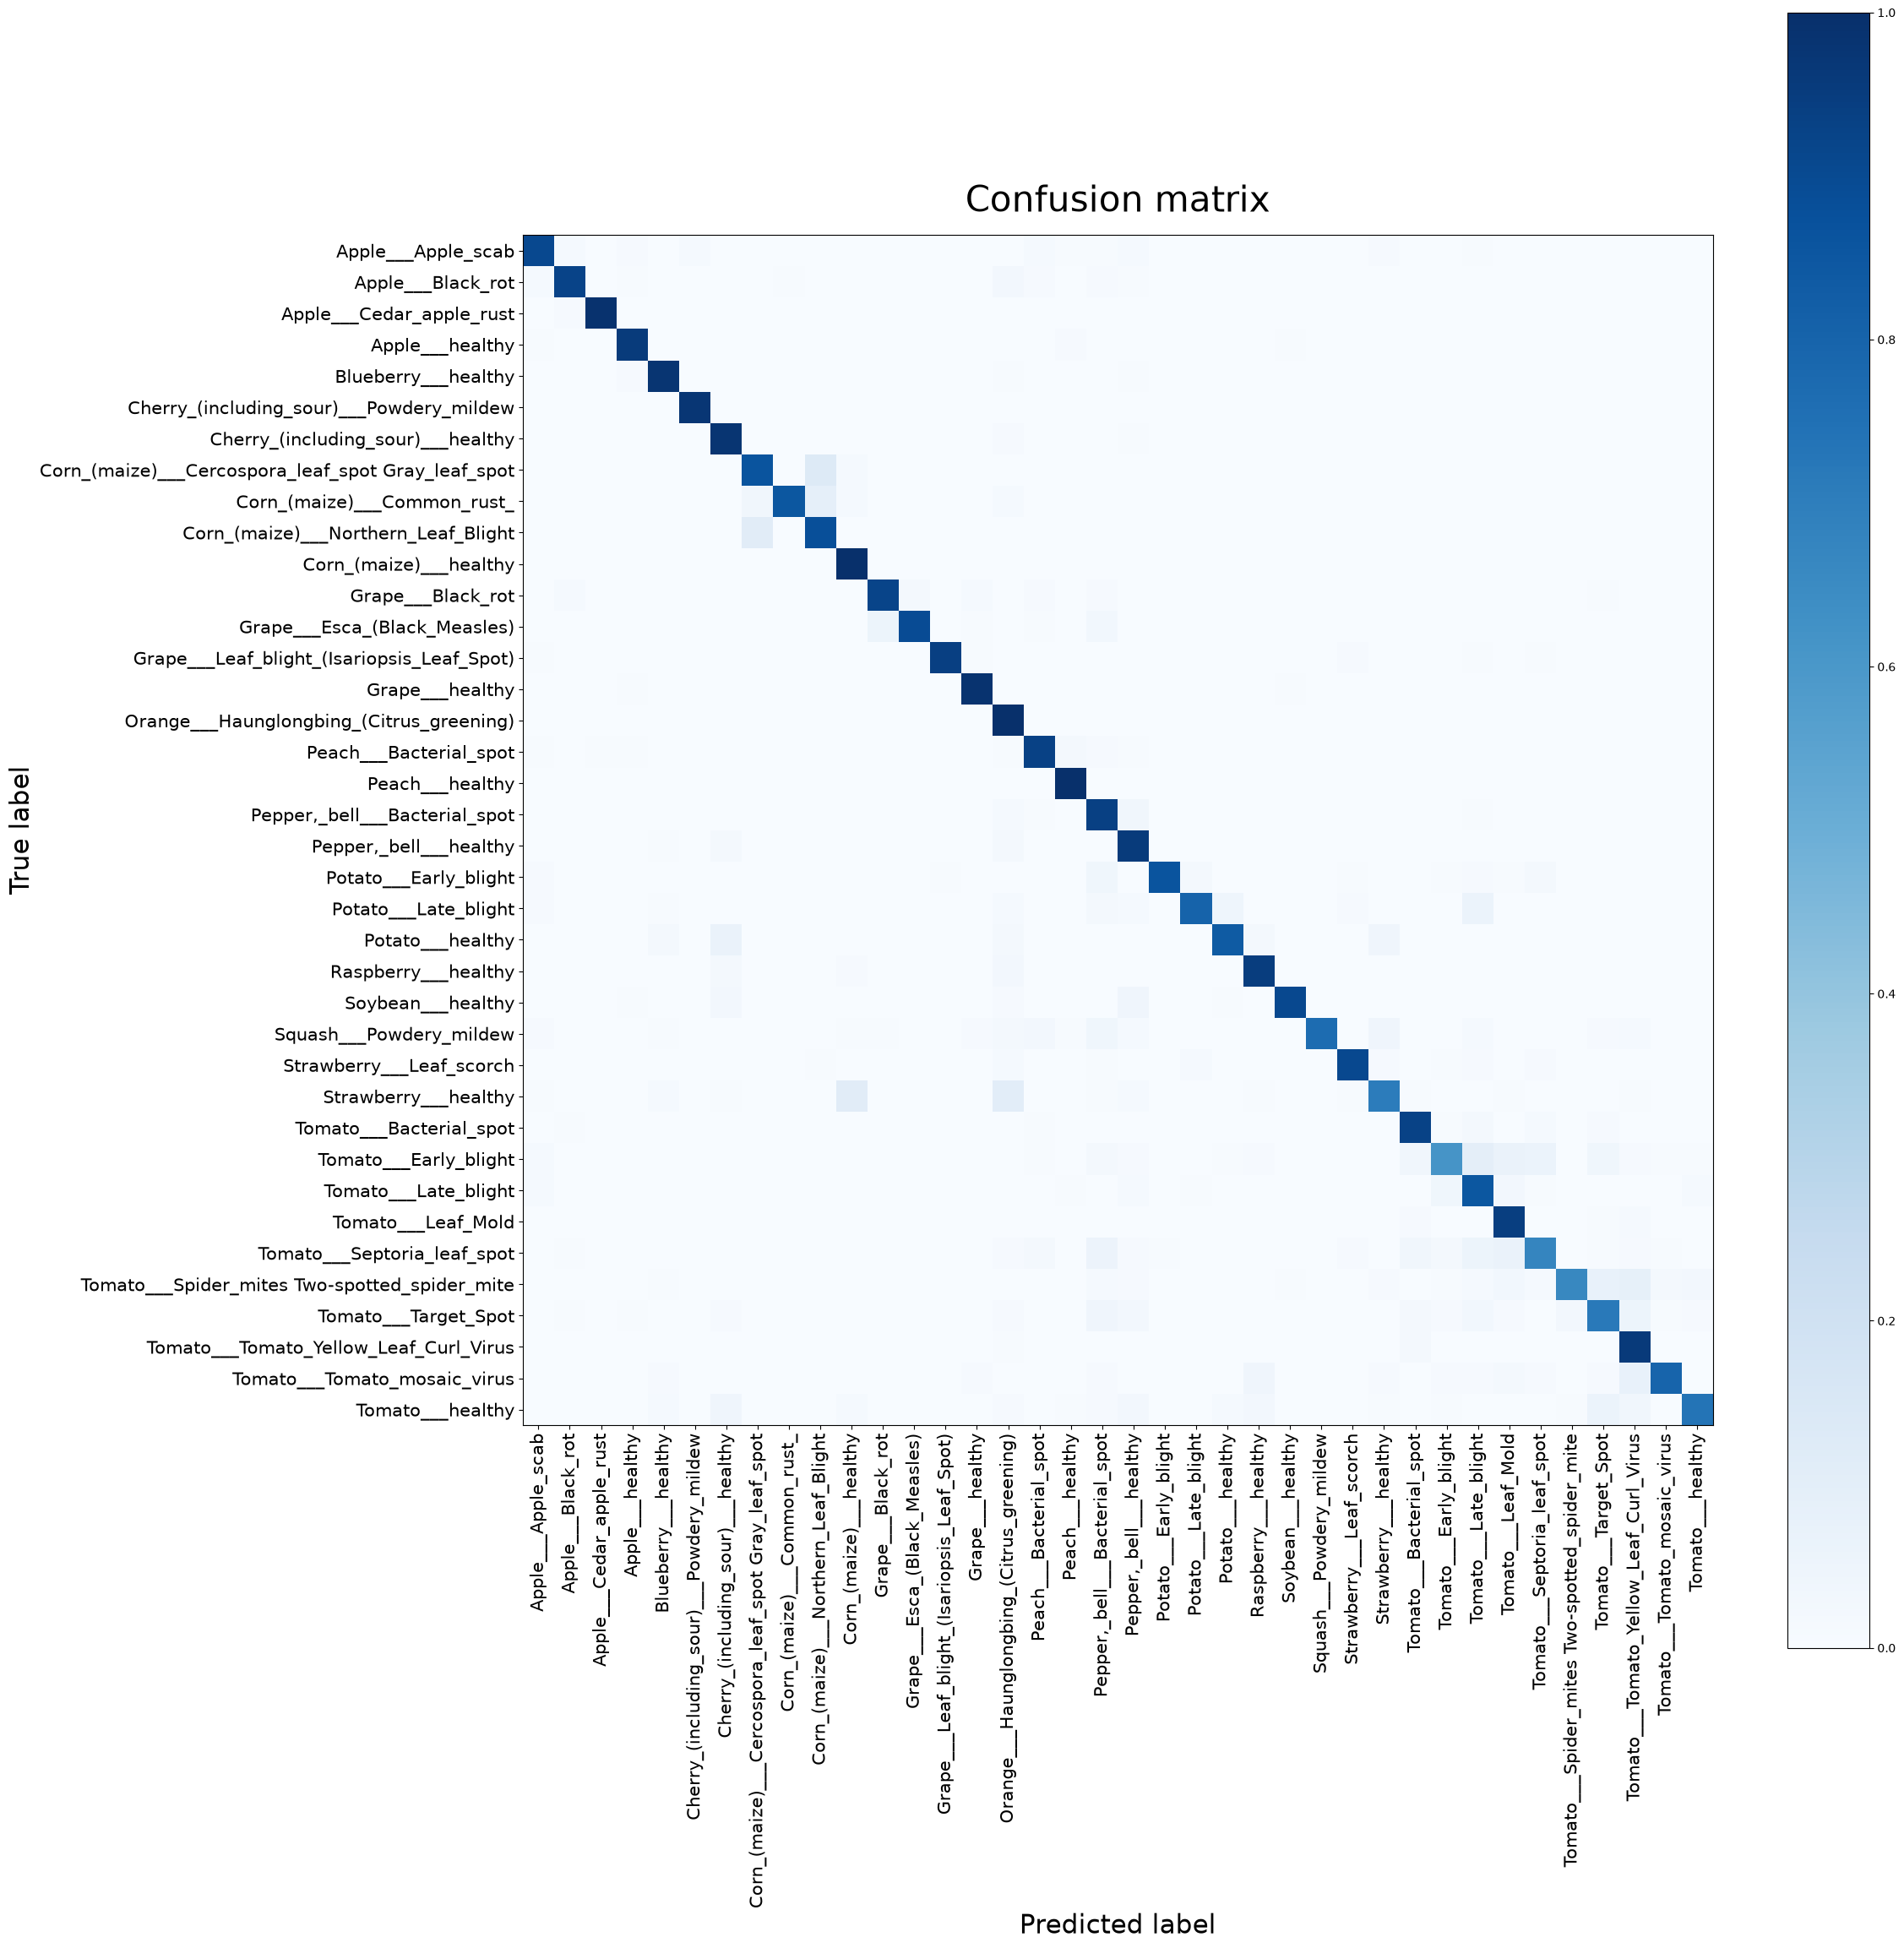

In [62]:
fig, ax = plt.subplots(figsize = (24, 24))

conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_names)
conf_matrix_display.plot(cmap = plt.cm.Blues, ax = ax, xticks_rotation = "vertical", include_values = False)
ax.tick_params(axis='x', labelsize = 15)
ax.tick_params(axis='y', labelsize = 15)

plt.title("Confusion matrix", pad = 20, fontsize = 30)
plt.xlabel("Predicted label", fontsize = 22)
plt.ylabel("True label", fontsize = 22)
plt.tight_layout()
plt.show()

The confusion matrix provides visualization of the model's classification performance across all 38 plant disease categories. The distinct dark blue diagonal showing high classification accuracy across the majority of classes, indicating that the model learned highly discriminative visual features.
Around 11% of the validation samples are misclassified. I assume this might be caused by similar looking leaf spots. I will check that in the next steps.